<a href="https://colab.research.google.com/github/BriceGyb/Vision/blob/brats-africa-segmentation/Copie_de_CamVid_Segmentation_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 8INF804 — Segmentation Sémantique CamVid
## DeepLabv3+ (CNN) vs SegFormer-B2 (Transformer)

**Instructions Colab :**
1. `Exécution > Modifier le type d'exécution > GPU (T4)`
2. Exécutez toutes les cellules dans l'ordre (`Ctrl+F9`)
3. À la fin, téléchargez le dossier `results/` avec les checkpoints et figures

In [ ]:
# ── Vérification GPU ──────────────────────────────────────────────────────────
import torch
print('CUDA :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU  :', torch.cuda.get_device_name(0))
    print('VRAM :', round(torch.cuda.get_device_properties(0).total_memory/1e9,1), 'GB')

CUDA : True
GPU  : Tesla T4
VRAM : 15.6 GB


In [ ]:
# ── Installation des dépendances ──────────────────────────────────────────────
!pip install -q transformers scikit-image opencv-python-headless

In [ ]:
# ── Upload du dataset CamVid-main.zip ─────────────────────────────────────────
# Option A : upload manuel (lent)
# from google.colab import files
# uploaded = files.upload()  # uploader CamVid-main.zip
# !unzip -q CamVid-main.zip -d dataset/

# Option B : depuis Google Drive (recommandé si vous avez mis le dataset sur Drive)
from google.colab import drive
drive.mount('/content/drive')
# Ajustez le chemin selon votre Drive :
!cp -r "/content/drive/MyDrive/dataset/." /content/dataset/
print('Dataset copié.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset copié.


In [ ]:
%%writefile -a /dev/null
# ── Vérification structure dataset ───────────────────────────────────────────
import os
base = '/content/dataset/CamVid-main'
print('Contenu:', os.listdir(base))
print('RGB images:', len(os.listdir(f'{base}/CamVid_RGB')))
print('Gray masks:', len(os.listdir(f'{base}/CamVidGray')))

Appending to /dev/null


In [ ]:
import os
base = '/content/dataset/CamVid-main'
print('Contenu:', os.listdir(base))
print('RGB images:', len(os.listdir(f'{base}/CamVid_RGB')))
print('Gray masks:', len(os.listdir(f'{base}/CamVidGray')))

Contenu: ['CamVid_RGB', 'CamVidGray', 'camvid_trainval.txt', 'SegNetanno', 'README.md', 'camvid_test.txt', 'camvid_train.txt', 'CamVidColor11', 'camvid_val.txt', '.gitignore', 'LICENSE', 'camvid_data.py', 'CamVid_Label']
RGB images: 701
Gray masks: 701


In [ ]:
# ── Création de la structure du projet ───────────────────────────────────────
os.makedirs('/content/project/data', exist_ok=True)
os.makedirs('/content/project/models', exist_ok=True)
os.makedirs('/content/project/training', exist_ok=True)
os.makedirs('/content/project/evaluation', exist_ok=True)
os.makedirs('/content/results', exist_ok=True)
print('Répertoires créés.')

Répertoires créés.


In [ ]:
%%writefile /content/project/data/__init__.py


Writing /content/project/data/__init__.py


In [ ]:
%%writefile /content/project/data/camvid_dataset.py
import os
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset

CAMVID_CLASSES = ['Sky','Building','Pole','Road','Pavement','Tree','SignSymbol','Fence','Car','Pedestrian','Bicyclist']
NUM_CLASSES = 11
IGNORE_INDEX = 255
CAMVID_CLASS_COLORS = [(128,128,128),(128,0,0),(192,192,128),(128,64,128),(60,40,222),(128,128,0),(192,128,128),(64,64,128),(64,0,128),(64,64,0),(0,128,192)]

class CamVidDataset(Dataset):
    def __init__(self, root, split_file, transform=None):
        self.root = root
        self.transform = transform
        self.samples = []
        with open(split_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 2:
                    self.samples.append((os.path.join(root, parts[0]), os.path.join(root, parts[1])))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, lbl_path = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        label = Image.open(lbl_path)
        if self.transform is not None:
            image, label = self.transform(image, label)
        return image, label

def mask_to_color(mask_np):
    h, w = mask_np.shape
    color = np.zeros((h, w, 3), dtype=np.uint8)
    for cls_id, rgb in enumerate(CAMVID_CLASS_COLORS):
        color[mask_np == cls_id] = rgb
    return color

Writing /content/project/data/camvid_dataset.py


In [ ]:
%%writefile /content/project/data/transforms.py
import random
import numpy as np
import torch
import torchvision.transforms.functional as TF
from PIL import Image

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class TrainTransform:
    def __init__(self, base_size=560, crop_size=512):
        self.base_size = base_size
        self.crop_size = crop_size

    def __call__(self, image, mask):
        image = TF.resize(image, (self.base_size, self.base_size), interpolation=Image.BILINEAR)
        mask  = TF.resize(mask,  (self.base_size, self.base_size), interpolation=Image.NEAREST)
        w, h = image.size
        th = tw = self.crop_size
        i = random.randint(0, h - th)
        j = random.randint(0, w - tw)
        image = TF.crop(image, i, j, th, tw)
        mask  = TF.crop(mask,  i, j, th, tw)
        if random.random() > 0.5:
            image = TF.hflip(image); mask = TF.hflip(mask)
        if random.random() > 0.5:
            image = TF.adjust_brightness(image, random.uniform(0.7, 1.3))
            image = TF.adjust_contrast(image,   random.uniform(0.7, 1.3))
            image = TF.adjust_saturation(image, random.uniform(0.7, 1.3))
        image = TF.normalize(TF.to_tensor(image), IMAGENET_MEAN, IMAGENET_STD)
        mask  = torch.from_numpy(np.array(mask, dtype=np.int64))
        return image, mask

class ValTransform:
    def __init__(self, size=512):
        self.size = size
    def __call__(self, image, mask):
        image = TF.resize(image, (self.size, self.size), interpolation=Image.BILINEAR)
        mask  = TF.resize(mask,  (self.size, self.size), interpolation=Image.NEAREST)
        image = TF.normalize(TF.to_tensor(image), IMAGENET_MEAN, IMAGENET_STD)
        mask  = torch.from_numpy(np.array(mask, dtype=np.int64))
        return image, mask

Writing /content/project/data/transforms.py


In [ ]:
%%writefile /content/project/evaluation/__init__.py


Writing /content/project/evaluation/__init__.py


In [ ]:
%%writefile /content/project/evaluation/metrics.py
import numpy as np
import torch

NUM_CLASSES = 11
IGNORE_INDEX = 255

class SegmentationMetrics:
    def __init__(self, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.confusion = np.zeros((num_classes, num_classes), dtype=np.int64)

    def reset(self): self.confusion[:] = 0

    def update(self, preds, targets):
        if isinstance(preds, torch.Tensor): preds = preds.cpu().numpy()
        if isinstance(targets, torch.Tensor): targets = targets.cpu().numpy()
        preds = preds.flatten().astype(np.int64)
        targets = targets.flatten().astype(np.int64)
        valid = targets != self.ignore_index
        preds = np.clip(preds[valid], 0, self.num_classes-1)
        targets = np.clip(targets[valid], 0, self.num_classes-1)
        np.add.at(self.confusion, (targets, preds), 1)

    def compute(self):
        conf = self.confusion.astype(np.float64)
        tp = np.diag(conf); fp = conf.sum(0)-tp; fn = conf.sum(1)-tp
        denom = tp+fp+fn
        iou = np.where(denom>0, tp/denom, np.nan)
        miou = float(np.nanmean(iou))
        pixel_acc = float(tp.sum()/conf.sum()) if conf.sum()>0 else 0.0
        mean_acc = float(np.nanmean(np.where(conf.sum(1)>0, tp/conf.sum(1), np.nan)))
        precision = np.where(tp+fp>0, tp/(tp+fp), np.nan)
        recall    = np.where(tp+fn>0, tp/(tp+fn), np.nan)
        f1 = np.where((~np.isnan(precision))&(~np.isnan(recall))&(precision+recall>0),
                      2*precision*recall/(precision+recall), np.nan)
        return {'mIoU': miou, 'pixel_acc': pixel_acc, 'mean_acc': mean_acc,
                'f1_macro': float(np.nanmean(f1)), 'iou_per_class': iou.tolist(),
                'f1_per_class': f1.tolist()}

def evaluate_model(model, dataloader, device, num_classes=NUM_CLASSES):
    model.eval()
    metrics = SegmentationMetrics(num_classes=num_classes)
    with torch.no_grad():
        for images, masks in dataloader:
            logits = model(images.to(device))
            metrics.update(logits.argmax(dim=1), masks)
    return metrics.compute()

Writing /content/project/evaluation/metrics.py


In [ ]:
%%writefile /content/project/models/__init__.py


Writing /content/project/models/__init__.py


In [ ]:
%%writefile /content/project/models/deeplabv3plus.py
import torch
import torch.nn as nn
from torchvision.models.segmentation import deeplabv3_resnet50

class DeepLabWrapper(nn.Module):
    def __init__(self, pretrained_backbone=False, num_classes=11):
        super().__init__()
        self.model = deeplabv3_resnet50(
            weights=None,
            weights_backbone='IMAGENET1K_V1' if pretrained_backbone else None,
            num_classes=num_classes, aux_loss=True
        )
        if not pretrained_backbone:
            for m in self.model.modules():
                if isinstance(m, nn.Conv2d):
                    nn.init.xavier_uniform_(m.weight)
                    if m.bias is not None: nn.init.zeros_(m.bias)
                elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                    nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.model(x)['out']

    def forward_with_aux(self, x):
        out = self.model(x)
        return out['out'], out.get('aux')

Writing /content/project/models/deeplabv3plus.py


In [ ]:
%%writefile /content/project/models/segformer.py
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import SegformerForSemanticSegmentation

class SegFormerWrapper(nn.Module):
    def __init__(self, pretrained_backbone=False, num_classes=11):
        super().__init__()
        self.model = SegformerForSemanticSegmentation.from_pretrained(
            'nvidia/mit-b2', num_labels=num_classes, ignore_mismatched_sizes=True,
            id2label={i: str(i) for i in range(num_classes)},
            label2id={str(i): i for i in range(num_classes)}
        )
        if not pretrained_backbone:
            for module in self.model.modules():
                if hasattr(module, 'reset_parameters'):
                    module.reset_parameters()
                elif isinstance(module, nn.Linear):
                    nn.init.xavier_uniform_(module.weight)
                    if module.bias is not None: nn.init.zeros_(module.bias)

    def forward(self, x):
        logits = self.model(pixel_values=x).logits
        return F.interpolate(logits, size=x.shape[-2:], mode='bilinear', align_corners=False)

Writing /content/project/models/segformer.py


In [ ]:
# ── Fonctions d'entraînement et d'évaluation ──────────────────────────────────
import sys
sys.path.insert(0, '/content/project')

import os, json, time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

from data.camvid_dataset import CamVidDataset
from data.transforms import TrainTransform, ValTransform
from evaluation.metrics import SegmentationMetrics, evaluate_model

DATASET_ROOT = '/content/dataset/CamVid-main'
RESULTS_DIR  = '/content/results'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

CAMVID_WEIGHTS = torch.tensor(
    [0.306, 0.229, 4.545, 0.183, 0.568, 0.454, 2.273, 2.273, 0.568, 2.273, 5.000]
).to(DEVICE)

def make_loaders(batch_train=8, batch_val=4):
    train_ds = CamVidDataset(DATASET_ROOT, f'{DATASET_ROOT}/camvid_train.txt', TrainTransform())
    val_ds   = CamVidDataset(DATASET_ROOT, f'{DATASET_ROOT}/camvid_val.txt',   ValTransform())
    test_ds  = CamVidDataset(DATASET_ROOT, f'{DATASET_ROOT}/camvid_test.txt',  ValTransform())
    return (
        DataLoader(train_ds, batch_size=batch_train, shuffle=True,  num_workers=2, pin_memory=True, drop_last=True),
        DataLoader(val_ds,   batch_size=batch_val,   shuffle=False, num_workers=2, pin_memory=True),
        DataLoader(test_ds,  batch_size=batch_val,   shuffle=False, num_workers=2, pin_memory=True),
        test_ds
    )

def train_epoch(model, loader, optimizer, criterion, model_type, scaler):
    model.train()
    total = 0; n = 0
    for imgs, masks in tqdm(loader, leave=False, desc='Train'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        if scaler:
            with torch.amp.autocast('cuda'):
                if model_type == 'deeplabv3':
                    out = model.model(imgs)
                    loss = criterion(out['out'], masks) + 0.4*criterion(out.get('aux', out['out']), masks)
                else:
                    loss = criterion(model(imgs), masks)
            scaler.scale(loss).backward()
            if model_type == 'segformer':
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
        else:
            if model_type == 'deeplabv3':
                out = model.model(imgs)
                loss = criterion(out['out'], masks) + 0.4*criterion(out.get('aux', out['out']), masks)
            else:
                loss = criterion(model(imgs), masks)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            loss.backward(); optimizer.step()
        total += loss.item(); n += 1
    return total / max(n,1)

@torch.no_grad()
def val_epoch(model, loader, criterion):
    model.eval()
    m = SegmentationMetrics(); total = 0; n = 0
    for imgs, masks in loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        total += criterion(logits, masks.to(DEVICE)).item(); n += 1
        m.update(logits.argmax(1), masks)
    return total/max(n,1), m.compute()

def full_train(model, model_type, epochs, lr, lr_head=None, batch_train=8, save_name='model'):
    import math
    save_dir = f'{RESULTS_DIR}/{save_name}'
    os.makedirs(save_dir, exist_ok=True)
    # Dossier miroir sur Google Drive (survit aux déconnexions)
    drive_dir = f'/content/drive/MyDrive/results_8INF804/{save_name}'
    os.makedirs(drive_dir, exist_ok=True)
    criterion = nn.CrossEntropyLoss(weight=CAMVID_WEIGHTS, ignore_index=255)
    train_loader, val_loader, test_loader, _ = make_loaders(batch_train)
    use_amp = torch.cuda.is_available()
    scaler  = torch.amp.GradScaler('cuda') if use_amp else None

    if model_type == 'deeplabv3':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4, nesterov=True)
        scheduler = torch.optim.lr_scheduler.PolynomialLR(optimizer, total_iters=epochs, power=0.9)
    else:
        enc_params = [p for n,p in model.named_parameters() if 'segformer.encoder' in n]
        dec_params = [p for n,p in model.named_parameters() if 'segformer.encoder' not in n]
        optimizer = torch.optim.AdamW([{'params':enc_params,'lr':lr},{'params':dec_params,'lr':lr_head}], weight_decay=0.01)
        warmup = max(1, epochs//10)
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer,
            lambda e: (e+1)/warmup if e<warmup else 0.5*(1+math.cos(math.pi*(e-warmup)/max(1,epochs-warmup))))

    best_miou = 0; patience = 15; history = {'train_loss':[], 'val_miou':[]}
    for epoch in range(1, epochs+1):
        t0 = time.time()
        tl = train_epoch(model, train_loader, optimizer, criterion, model_type, scaler)
        vl, vm = val_epoch(model, val_loader, criterion)
        miou = vm['mIoU']
        history['train_loss'].append(tl); history['val_miou'].append(miou)
        scheduler.step()
        print(f"Ep {epoch:3d}/{epochs} | TrainL={tl:.4f} | ValL={vl:.4f} | mIoU={miou:.4f} | PixAcc={vm['pixel_acc']:.4f} | {time.time()-t0:.1f}s")
        if miou > best_miou:
            best_miou = miou; patience = 15
            torch.save({'epoch':epoch,'model_state_dict':model.state_dict(),'miou':miou,'val_metrics':vm},
                       f'{save_dir}/best_model.pth')
            import shutil
            shutil.copy(f'{save_dir}/best_model.pth', f'{drive_dir}/best_model.pth')
            print(f'  -> Sauvegarde Drive: {drive_dir}/best_model.pth')
            print(f"  -> Nouveau meilleur mIoU={best_miou:.4f}")
        else:
            patience -= 1
            if patience <= 0:
                print(f"  Early stopping. Best mIoU={best_miou:.4f}"); break

    with open(f'{save_dir}/history.json','w') as f: json.dump(history, f)
    import shutil
    shutil.copy(f'{save_dir}/history.json', f'{drive_dir}/history.json')
    # Évaluation test set
    ckpt = torch.load(f'{save_dir}/best_model.pth', map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    test_metrics = evaluate_model(model, test_loader, DEVICE)
    with open(f'{save_dir}/test_metrics.json','w') as f: json.dump(test_metrics, f, indent=2)
    shutil.copy(f'{save_dir}/test_metrics.json', f'{drive_dir}/test_metrics.json')
    print(f'  -> Métriques sauvegardées sur Drive.')
    print(f"\nTest set — mIoU={test_metrics['mIoU']:.4f} | PixAcc={test_metrics['pixel_acc']:.4f} | F1={test_metrics['f1_macro']:.4f}")
    return history, test_metrics

print('Fonctions chargées.')

Device: cuda
Fonctions chargées.


## BLOC 1 — From Scratch

In [ ]:
# ── DeepLabv3+ BLOC 1 (From Scratch) ─────────────────────────────────────────
from models.deeplabv3plus import DeepLabWrapper
model_dl_s1 = DeepLabWrapper(pretrained_backbone=False).to(DEVICE)
print(f"Paramètres: {sum(p.numel() for p in model_dl_s1.parameters())/1e6:.1f}M")

hist_dl_s1, metrics_dl_s1 = full_train(
    model_dl_s1, 'deeplabv3', epochs=100, lr=0.01, batch_train=8,
    save_name='deeplabv3_bloc1'
)

Paramètres: 42.0M


Train:   0%|          | 0/45 [00:00<?, ?it/s]

/content/project/evaluation/metrics.py:33: RuntimeWarning: invalid value encountered in divide
  precision = np.where(tp+fp>0, tp/(tp+fp), np.nan)
/content/project/evaluation/metrics.py:36: RuntimeWarning: invalid value encountered in divide
  2*precision*recall/(precision+recall), np.nan)


Ep   1/100 | TrainL=2.6667 | ValL=3.0325 | mIoU=0.1859 | PixAcc=0.5567 | 48.3s
  -> Sauvegarde Drive: /content/drive/MyDrive/results_8INF804/deeplabv3_bloc1/best_model.pth
  -> Nouveau meilleur mIoU=0.1859


Train:   0%|          | 0/45 [00:00<?, ?it/s]

...

Ep  64/100 | TrainL=0.3991 | ValL=0.5700 | mIoU=0.5976 | PixAcc=0.8901 | 51.4s


Train:   0%|          | 0/45 [00:00<?, ?it/s]

Ep  65/100 | TrainL=0.3899 | ValL=0.4769 | mIoU=0.6020 | PixAcc=0.8859 | 51.5s


Train:   0%|          | 0/45 [00:00<?, ?it/s]

Ep  66/100 | TrainL=0.3947 | ValL=0.5809 | mIoU=0.6102 | PixAcc=0.8945 | 51.3s
  Early stopping. Best mIoU=0.6110
  -> Métriques sauvegardées sur Drive.

Test set — mIoU=0.4693 | PixAcc=0.8097 | F1=0.5854


In [ ]:
# ── SegFormer-B2 BLOC 1 (From Scratch) ───────────────────────────────────────
from models.segformer import SegFormerWrapper
model_sf_s1 = SegFormerWrapper(pretrained_backbone=False).to(DEVICE)
print(f"Paramètres: {sum(p.numel() for p in model_sf_s1.parameters())/1e6:.1f}M")

hist_sf_s1, metrics_sf_s1 = full_train(
    model_sf_s1, 'segformer', epochs=80, lr=6e-5, lr_head=6e-4, batch_train=4,
    save_name='segformer_bloc1'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

...

Ep  78/80 | TrainL=0.2340 | ValL=0.5362 | mIoU=0.6136 | PixAcc=0.9020 | 38.8s


Train:   0%|          | 0/91 [00:00<?, ?it/s]

Ep  79/80 | TrainL=0.2337 | ValL=0.5406 | mIoU=0.6132 | PixAcc=0.9019 | 37.3s


Train:   0%|          | 0/91 [00:00<?, ?it/s]

Ep  80/80 | TrainL=0.2337 | ValL=0.5502 | mIoU=0.6143 | PixAcc=0.9025 | 38.5s
  -> Métriques sauvegardées sur Drive.

Test set — mIoU=0.4673 | PixAcc=0.8017 | F1=0.5890


## BLOC 2 — Pré-entraîné ImageNet

In [ ]:
# ── DeepLabv3+ BLOC 2 (ImageNet) ─────────────────────────────────────────────
model_dl_s2 = DeepLabWrapper(pretrained_backbone=True).to(DEVICE)

hist_dl_s2, metrics_dl_s2 = full_train(
    model_dl_s2, 'deeplabv3', epochs=100, lr=0.01, batch_train=8,
    save_name='deeplabv3_bloc2'
)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


Train:   0%|          | 0/45 [00:00<?, ?it/s]

Ep   1/100 | TrainL=1.6438 | ValL=0.7121 | mIoU=0.4743 | PixAcc=0.7719 | 51.0s
  -> Sauvegarde Drive: /content/drive/MyDrive/results_8INF804/deeplabv3_bloc2/best_model.pth
  -> Nouveau meilleur mIoU=0.4743


Train:   0%|          | 0/45 [00:00<?, ?it/s]

...

Ep  46/100 | TrainL=0.2216 | ValL=0.2635 | mIoU=0.7339 | PixAcc=0.9382 | 50.7s


Train:   0%|          | 0/45 [00:00<?, ?it/s]

Ep  47/100 | TrainL=0.2200 | ValL=0.2906 | mIoU=0.7327 | PixAcc=0.9383 | 50.8s


Train:   0%|          | 0/45 [00:00<?, ?it/s]

Ep  48/100 | TrainL=0.2195 | ValL=0.2700 | mIoU=0.7340 | PixAcc=0.9368 | 50.6s
  Early stopping. Best mIoU=0.7365
  -> Métriques sauvegardées sur Drive.

Test set — mIoU=0.6605 | PixAcc=0.9020 | F1=0.7747


In [ ]:
# ── SegFormer-B2 BLOC 2 (ImageNet) ───────────────────────────────────────────
model_sf_s2 = SegFormerWrapper(pretrained_backbone=True).to(DEVICE)

hist_sf_s2, metrics_sf_s2 = full_train(
    model_sf_s2, 'segformer', epochs=80, lr=6e-5, lr_head=6e-4, batch_train=4,
    save_name='segformer_bloc2'
)

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

Train:   0%|          | 0/91 [00:00<?, ?it/s]

Ep   1/80 | TrainL=1.0457 | ValL=0.5198 | mIoU=0.5695 | PixAcc=0.8528 | 37.9s
  -> Sauvegarde Drive: /content/drive/MyDrive/results_8INF804/segformer_bloc2/best_model.pth
  -> Nouveau meilleur mIoU=0.5695


Train:   0%|          | 0/91 [00:00<?, ?it/s]

...

Ep  60/80 | TrainL=0.0954 | ValL=0.2617 | mIoU=0.7867 | PixAcc=0.9539 | 38.2s


Train:   0%|          | 0/91 [00:00<?, ?it/s]

Ep  61/80 | TrainL=0.0945 | ValL=0.2371 | mIoU=0.7849 | PixAcc=0.9533 | 37.6s


Train:   0%|          | 0/91 [00:00<?, ?it/s]

Ep  62/80 | TrainL=0.0947 | ValL=0.2518 | mIoU=0.7837 | PixAcc=0.9528 | 38.1s
  Early stopping. Best mIoU=0.7882
  -> Métriques sauvegardées sur Drive.

Test set — mIoU=0.7026 | PixAcc=0.9216 | F1=0.8087


## Visualisations

In [ ]:
# ── Tableau comparatif final ──────────────────────────────────────────────────
import json

configs = [
    ('deeplabv3_bloc1', 'DeepLabv3+ Scratch'),
    ('segformer_bloc1',  'SegFormer Scratch'),
    ('deeplabv3_bloc2', 'DeepLabv3+ ImageNet'),
    ('segformer_bloc2',  'SegFormer ImageNet'),
]

print(f"{'Configuration':<30} {'mIoU':>8} {'PixAcc':>8} {'MeanAcc':>9} {'F1':>8}")
print('-'*68)
all_metrics = {}
for folder, label in configs:
    path = f'/content/results/{folder}/test_metrics.json'
    if os.path.exists(path):
        with open(path) as f: m = json.load(f)
        all_metrics[label] = m
        print(f"{label:<30} {m['mIoU']:>8.4f} {m['pixel_acc']:>8.4f} {m['mean_acc']:>9.4f} {m['f1_macro']:>8.4f}")

Configuration                      mIoU   PixAcc   MeanAcc       F1
--------------------------------------------------------------------
DeepLabv3+ Scratch               0.4693   0.8097    0.6390   0.5854
SegFormer Scratch                0.4673   0.8017    0.6406   0.5890
DeepLabv3+ ImageNet              0.6605   0.9020    0.8150   0.7747
SegFormer ImageNet               0.7026   0.9216    0.8284   0.8087


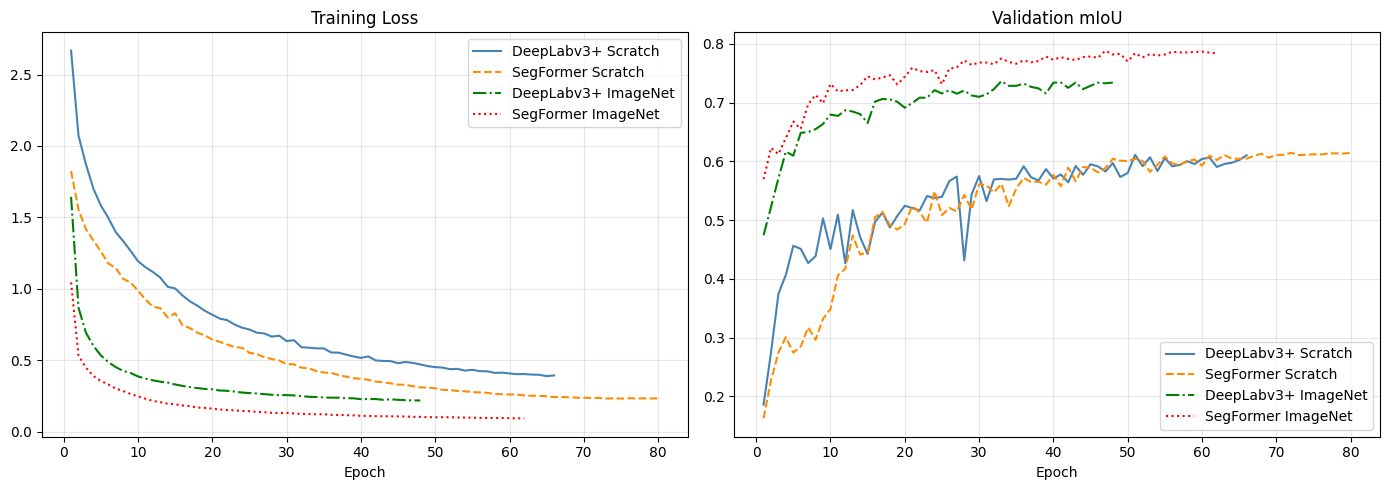

In [ ]:
# ── Courbes d'entraînement ────────────────────────────────────────────────────
import matplotlib.pyplot as plt

histories = {
    'DeepLabv3+ Scratch':  hist_dl_s1,
    'SegFormer Scratch':   hist_sf_s1,
    'DeepLabv3+ ImageNet': hist_dl_s2,
    'SegFormer ImageNet':  hist_sf_s2,
}
colors = ['steelblue','darkorange','green','red']
ls     = ['-','--','-.',':']

fig, axes = plt.subplots(1, 2, figsize=(14,5))
for idx, (lbl, h) in enumerate(histories.items()):
    ep = range(1, len(h['train_loss'])+1)
    axes[0].plot(ep, h['train_loss'], color=colors[idx], ls=ls[idx], label=lbl)
    ep2 = range(1, len(h['val_miou'])+1)
    axes[1].plot(ep2, h['val_miou'], color=colors[idx], ls=ls[idx], label=lbl)
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].set_title('Validation mIoU'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout()
plt.savefig('/content/results/training_curves.png', dpi=150)
import shutil; shutil.copy('/content/results/training_curves.png', '/content/drive/MyDrive/results_8INF804/training_curves.png')
plt.show()

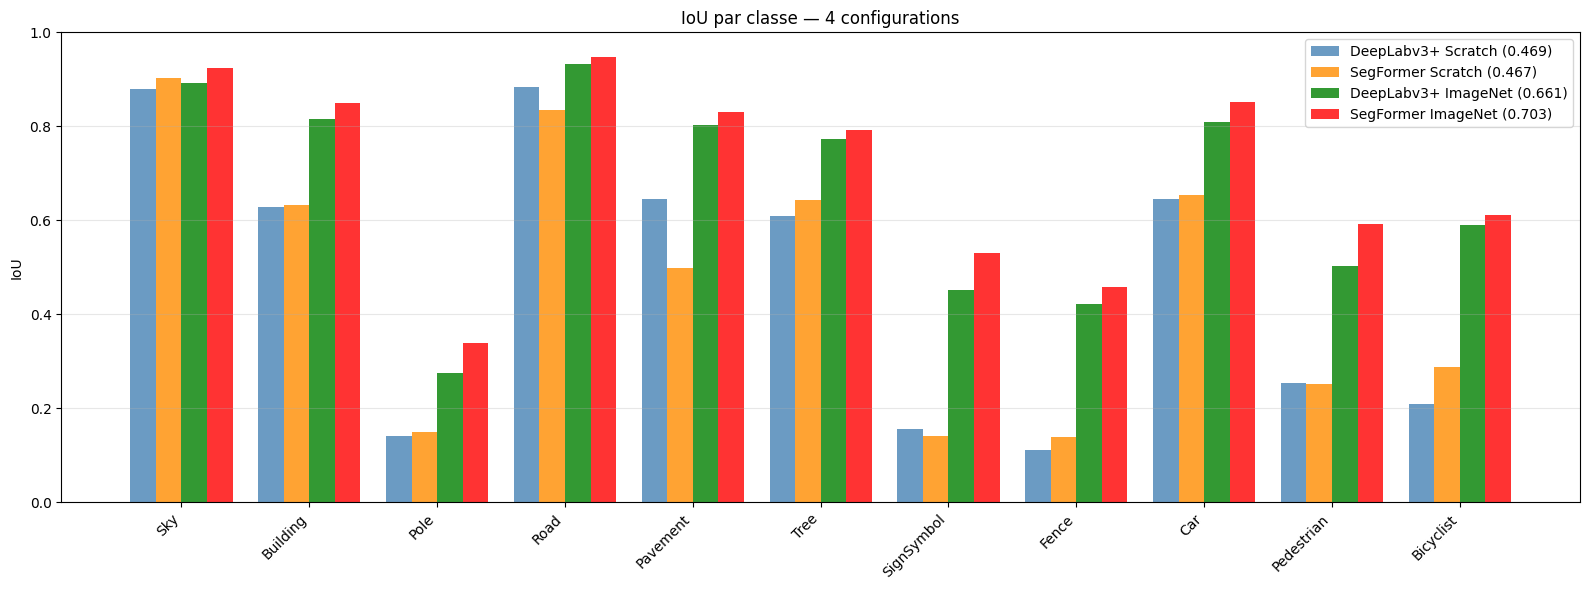

In [ ]:
# ── Barplot IoU par classe ────────────────────────────────────────────────────
import numpy as np
CLASSES = ['Sky','Building','Pole','Road','Pavement','Tree','SignSymbol','Fence','Car','Pedestrian','Bicyclist']

fig, ax = plt.subplots(figsize=(16,6))
x = np.arange(len(CLASSES)); w = 0.8/len(all_metrics)
for idx, (lbl, m) in enumerate(all_metrics.items()):
    iou = [v if not (isinstance(v,float) and v!=v) else 0.0 for v in m['iou_per_class']]
    ax.bar(x + (idx-len(all_metrics)/2+.5)*w, iou, w,
           label=f"{lbl} ({m['mIoU']:.3f})",
           color=colors[idx], alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_ylabel('IoU'); ax.set_title('IoU par classe — 4 configurations')
ax.legend(); ax.set_ylim(0,1); ax.grid(axis='y',alpha=.3)
plt.tight_layout()
plt.savefig('/content/results/iou_barplot.png', dpi=150)
import shutil; shutil.copy('/content/results/iou_barplot.png', '/content/drive/MyDrive/results_8INF804/iou_barplot.png')
plt.show()

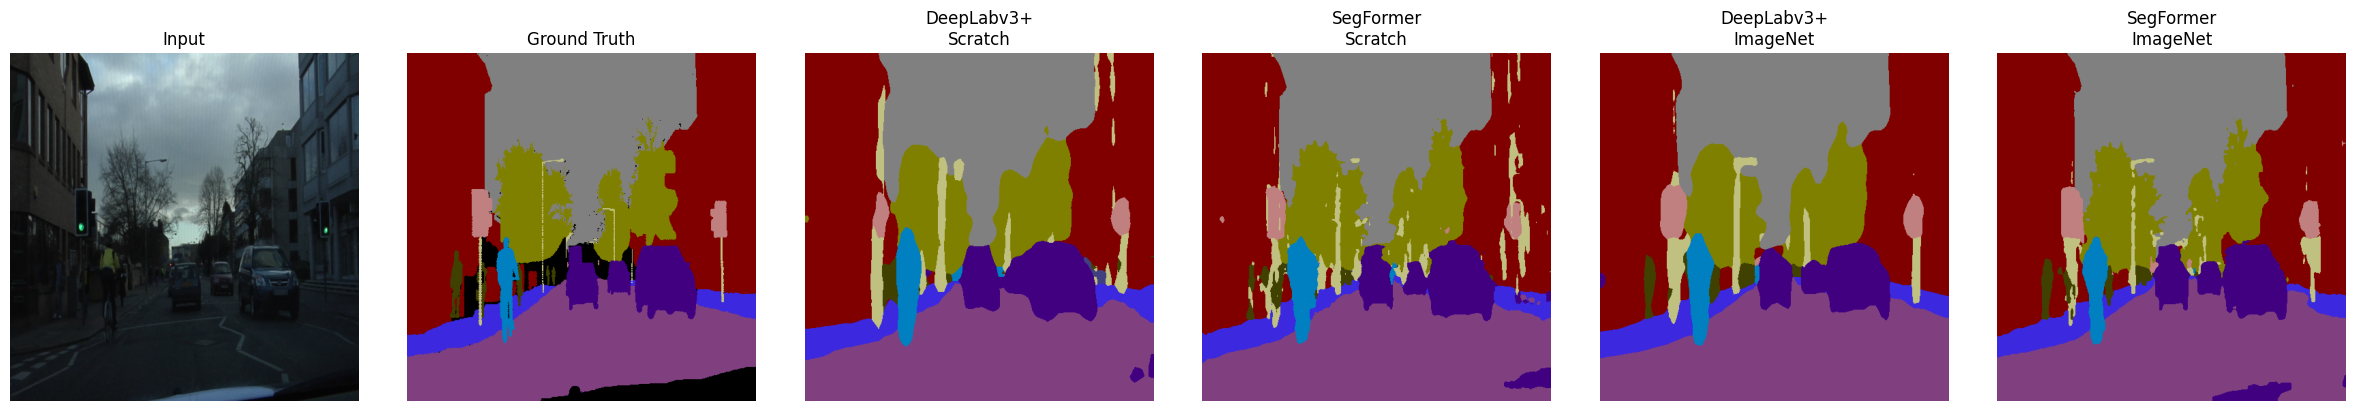

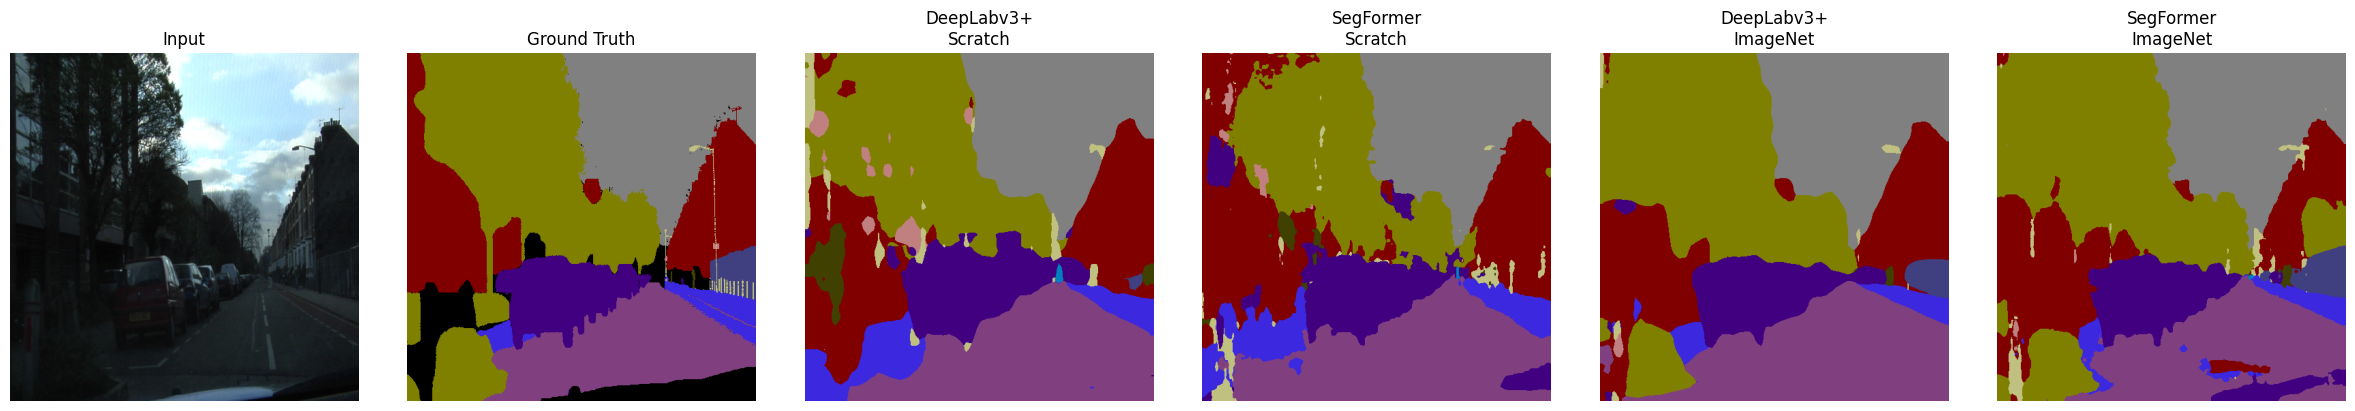

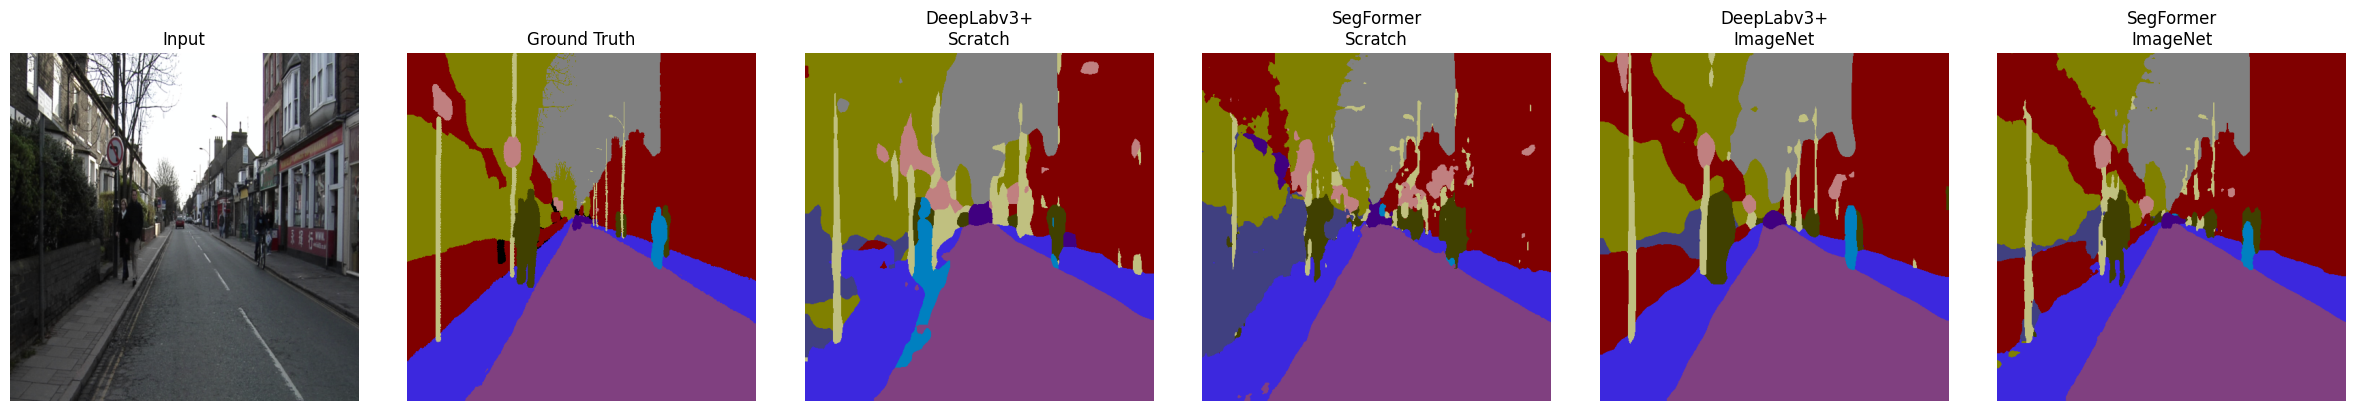

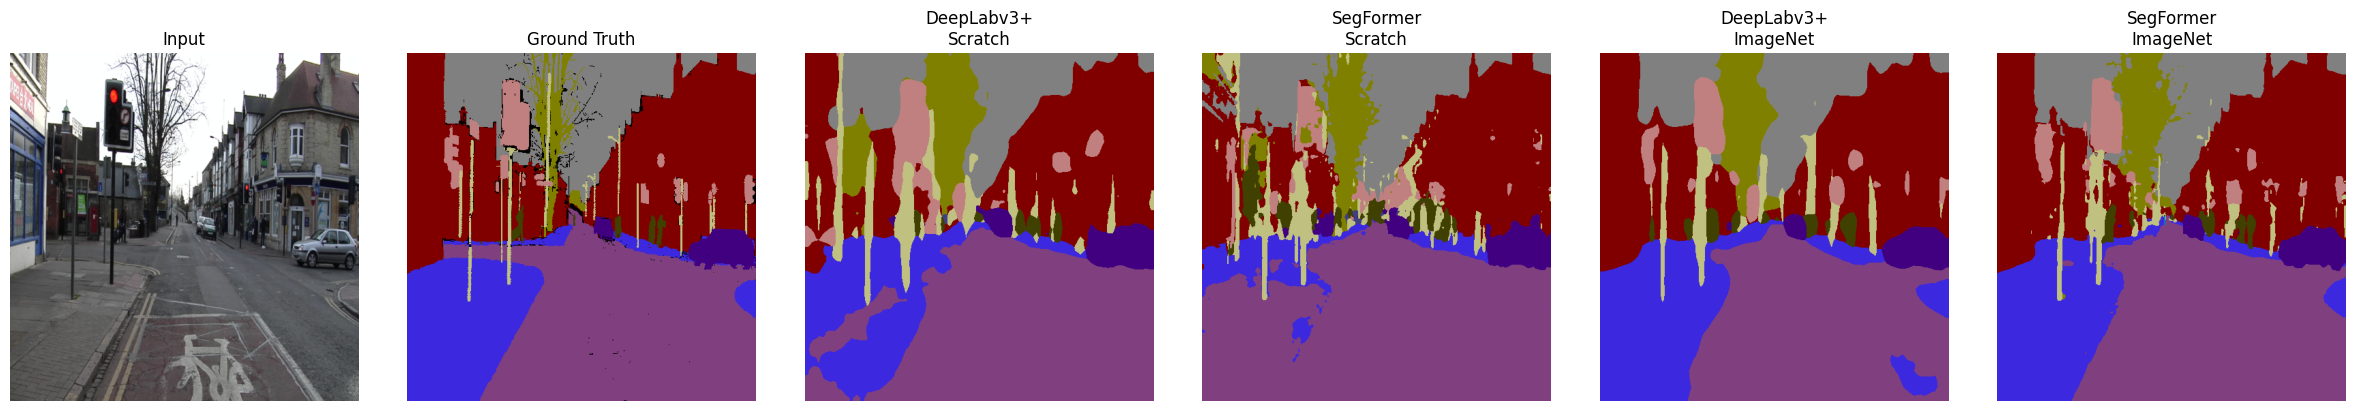

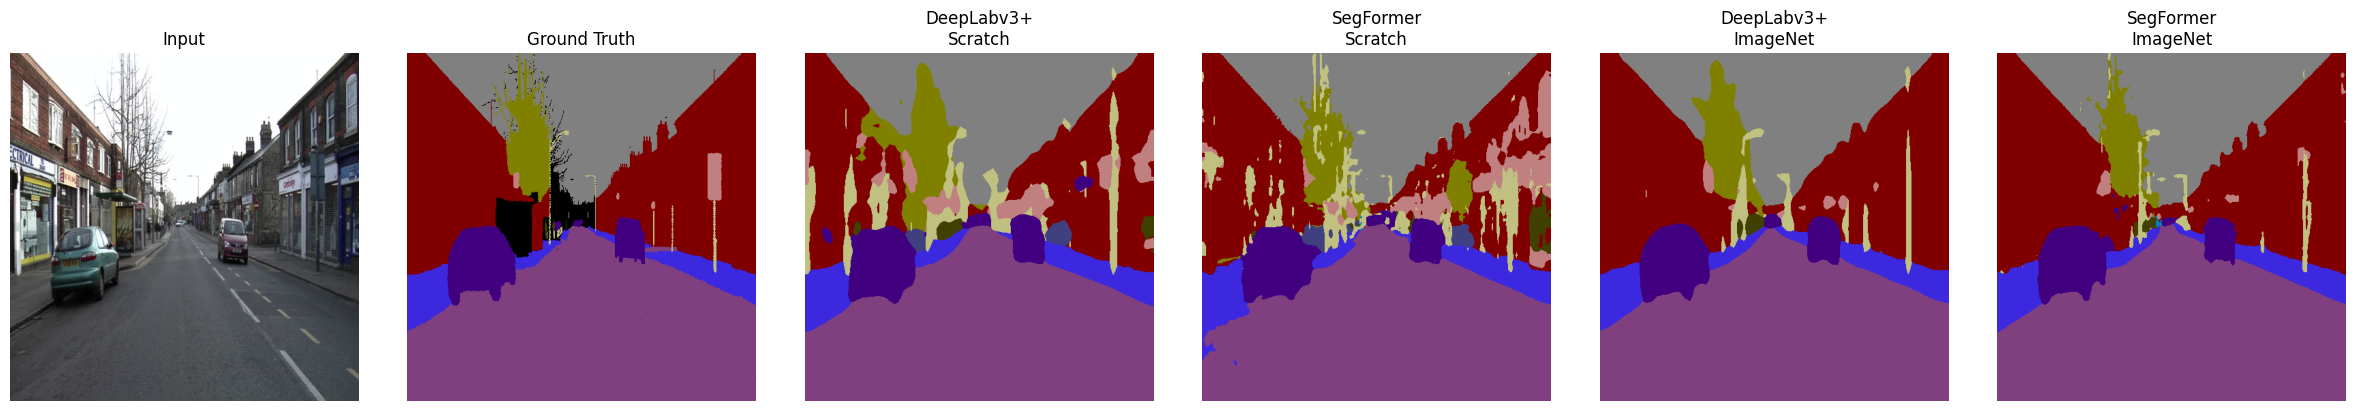

In [ ]:
# ── Exemples qualitatifs ──────────────────────────────────────────────────────
from data.camvid_dataset import CamVidDataset, mask_to_color
from data.transforms import ValTransform, IMAGENET_MEAN, IMAGENET_STD

test_ds = CamVidDataset(DATASET_ROOT, f'{DATASET_ROOT}/camvid_test.txt', ValTransform())

models_eval = {
    'DeepLabv3+\nScratch':  model_dl_s1,
    'SegFormer\nScratch':   model_sf_s1,
    'DeepLabv3+\nImageNet': model_dl_s2,
    'SegFormer\nImageNet':  model_sf_s2,
}

mean = np.array(IMAGENET_MEAN).reshape(3,1,1)
std  = np.array(IMAGENET_STD).reshape(3,1,1)

for sample_idx in [0, 50, 100, 150, 200]:
    img_t, mask_t = test_ds[sample_idx]
    img_np = (img_t.numpy()*std + mean).clip(0,1).transpose(1,2,0)
    gt_np  = mask_t.numpy()

    cols = 2 + len(models_eval)
    fig, axes = plt.subplots(1, cols, figsize=(4*cols, 4))
    axes[0].imshow(img_np); axes[0].set_title('Input'); axes[0].axis('off')
    axes[1].imshow(mask_to_color(gt_np)); axes[1].set_title('Ground Truth'); axes[1].axis('off')

    with torch.no_grad():
        for ax, (lbl, m) in zip(axes[2:], models_eval.items()):
            m.eval()
            pred = m(img_t.unsqueeze(0).to(DEVICE)).argmax(1).squeeze(0).cpu().numpy()
            ax.imshow(mask_to_color(pred)); ax.set_title(lbl); ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'/content/results/qualitative_{sample_idx}.png', dpi=100)
    import shutil; shutil.copy(f'/content/results/qualitative_{sample_idx}.png', f'/content/drive/MyDrive/results_8INF804/qualitative_{sample_idx}.png')
    plt.show()

In [ ]:
# ── Tests de robustesse ───────────────────────────────────────────────────────
from PIL import Image
import cv2
from skimage.util import random_noise

CORRUPTIONS = {
    'gaussian_noise':  [0.05, 0.10, 0.20],
    'gaussian_blur':   [3, 5, 7],
    'brightness_down': [0.5, 0.3, 0.1],
    'brightness_up':   [1.5, 2.0, 3.0],
    'salt_and_pepper': [0.01, 0.05, 0.10],
}

def corrupt(img_np, ctype, sev):
    img = img_np.astype(np.float32)/255.0
    if ctype == 'gaussian_noise': img = np.clip(img + np.random.normal(0,sev,img.shape), 0, 1)
    elif ctype == 'gaussian_blur':
        k = int(sev) if int(sev)%2==1 else int(sev)+1
        img = cv2.GaussianBlur((img*255).astype(np.uint8),(k,k),0).astype(np.float32)/255.0
    elif ctype in ('brightness_down','brightness_up'): img = np.clip(img*sev, 0, 1)
    elif ctype == 'salt_and_pepper': img = random_noise(img, mode='s&p', amount=sev).astype(np.float32)
    return img

test_ds_raw = CamVidDataset(DATASET_ROOT, f'{DATASET_ROOT}/camvid_test.txt', transform=None)
rob_results = {}

for mname, mdl in [('DeepLabv3+ Scratch',model_dl_s1),('SegFormer ImageNet',model_sf_s2)]:
    mdl.eval(); rob_results[mname] = {}
    for ctype, sevs in CORRUPTIONS.items():
        rob_results[mname][ctype] = {}
        for sev in sevs:
            m = SegmentationMetrics()
            with torch.no_grad():
                for img_pil, msk_pil in zip(
                        [Image.open(s[0]).convert('RGB') for s in test_ds_raw.samples[:50]],
                        [Image.open(s[1]) for s in test_ds_raw.samples[:50]]):
                    img_np = np.array(img_pil.resize((512,512), Image.BILINEAR))
                    img_c = corrupt(img_np, ctype, sev)
                    img_t = torch.from_numpy(img_c.transpose(2,0,1)).float()
                    img_t = (img_t - torch.tensor(IMAGENET_MEAN).view(3,1,1)) / torch.tensor(IMAGENET_STD).view(3,1,1)
                    msk_a = np.array(msk_pil.resize((512,512),Image.NEAREST), dtype=np.int64)
                    logits = mdl(img_t.unsqueeze(0).to(DEVICE))
                    m.update(logits.argmax(1), torch.from_numpy(msk_a).unsqueeze(0))
            rob_results[mname][ctype][sev] = m.compute()['mIoU']
        print(f"{mname} | {ctype}: {rob_results[mname][ctype]}")

with open('/content/results/robustness.json','w') as f: json.dump(rob_results,f,indent=2)
import shutil; shutil.copy('/content/results/robustness.json', '/content/drive/MyDrive/results_8INF804/robustness.json')
print('Robustesse calculée.')

/content/project/evaluation/metrics.py:36: RuntimeWarning: invalid value encountered in divide
  2*precision*recall/(precision+recall), np.nan)


DeepLabv3+ Scratch | gaussian_noise: {0.05: 0.29468391958440604, 0.1: 0.19963489021065897, 0.2: 0.0927465628734432}
DeepLabv3+ Scratch | gaussian_blur: {3: 0.4808307032484137, 5: 0.4624477486867582, 7: 0.4377999138815616}


/content/project/evaluation/metrics.py:33: RuntimeWarning: invalid value encountered in divide
  precision = np.where(tp+fp>0, tp/(tp+fp), np.nan)


DeepLabv3+ Scratch | brightness_down: {0.5: 0.3587099590191993, 0.3: 0.17392958127299404, 0.1: 0.044630894182632025}
DeepLabv3+ Scratch | brightness_up: {1.5: 0.5073952629195045, 2.0: 0.4824285073474534, 3.0: 0.4242139399530545}
DeepLabv3+ Scratch | salt_and_pepper: {0.01: 0.29497156614892056, 0.05: 0.168283710067786, 0.1: 0.073045027717092}
SegFormer ImageNet | gaussian_noise: {0.05: 0.5281167818017601, 0.1: 0.37556675081046226, 0.2: 0.2530155635192393}
SegFormer ImageNet | gaussian_blur: {3: 0.6849191342585701, 5: 0.6638754609879065, 7: 0.6321584988127248}
SegFormer ImageNet | brightness_down: {0.5: 0.7105190151651553, 0.3: 0.6957795731131751, 0.1: 0.5774534129168445}
SegFormer ImageNet | brightness_up: {1.5: 0.7179165495157994, 2.0: 0.7118907524529267, 3.0: 0.7003547415228311}
SegFormer ImageNet | salt_and_pepper: {0.01: 0.5857025081280933, 0.05: 0.2951708246953126, 0.1: 0.24753132872756944}
Robustesse calculée.


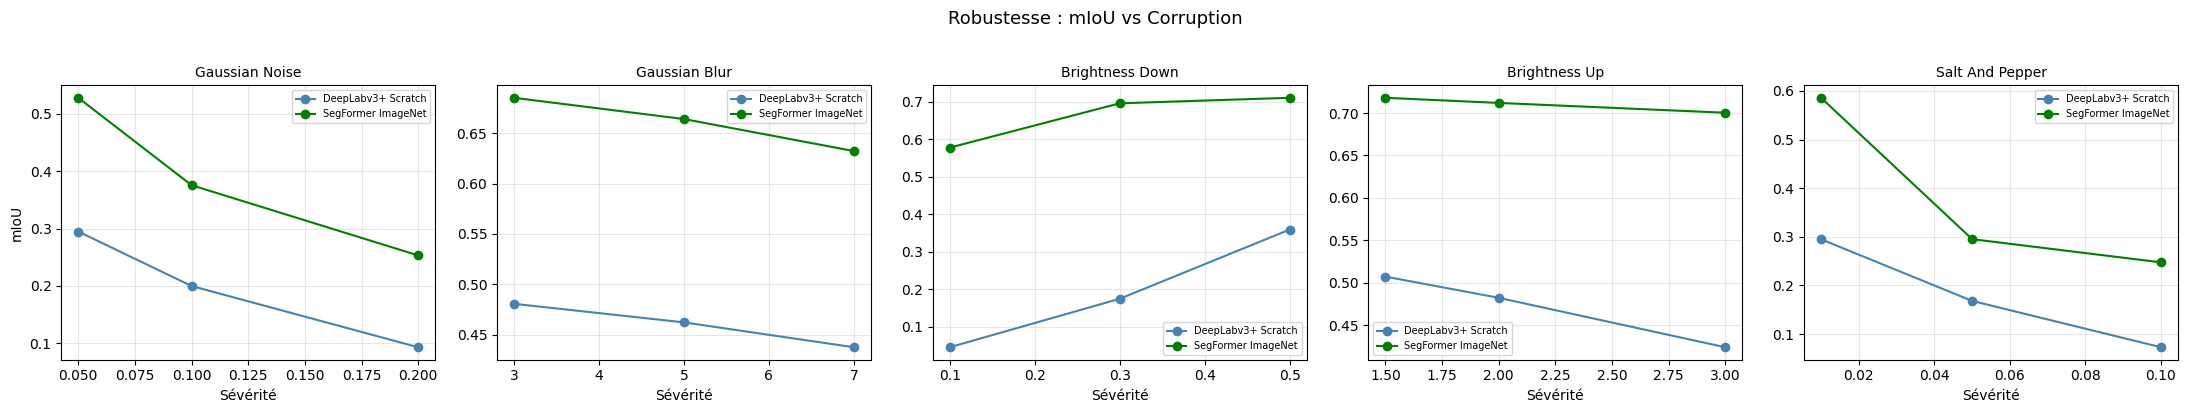

In [ ]:
# ── Courbes de robustesse ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22,4), sharey=False)
for ax, ctype in zip(axes, CORRUPTIONS.keys()):
    for idx, (mname, rob) in enumerate(rob_results.items()):
        sevs = sorted(rob[ctype].keys())
        ax.plot(sevs, [rob[ctype][s] for s in sevs], marker='o',
                color=colors[idx*2], label=mname)
    ax.set_title(ctype.replace('_',' ').title(), fontsize=10)
    ax.set_xlabel('Sévérité'); ax.legend(fontsize=7); ax.grid(alpha=.3)
axes[0].set_ylabel('mIoU')
plt.suptitle('Robustesse : mIoU vs Corruption', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('/content/results/robustness.png', dpi=150, bbox_inches='tight')
import shutil; shutil.copy('/content/results/robustness.png', '/content/drive/MyDrive/results_8INF804/robustness.png')
plt.show()

In [ ]:
# ── Téléchargement des résultats ──────────────────────────────────────────────
!zip -r /content/results_8INF804.zip /content/results/
from google.colab import files
files.download('/content/results_8INF804.zip')
print('Téléchargement lancé.')

updating: content/results/ (stored 0%)
updating: content/results/qualitative_150.png (deflated 1%)
updating: content/results/qualitative_100.png (deflated 1%)
updating: content/results/deeplabv3_bloc1/ (stored 0%)
updating: content/results/deeplabv3_bloc1/best_model.pth (deflated 8%)
updating: content/results/deeplabv3_bloc1/history.json (deflated 52%)
updating: content/results/deeplabv3_bloc1/test_metrics.json (deflated 51%)
updating: content/results/iou_barplot.png (deflated 22%)
updating: content/results/qualitative_0.png (deflated 1%)
updating: content/results/segformer_bloc2/ (stored 0%)
updating: content/results/segformer_bloc2/best_model.pth (deflated 7%)
updating: content/results/segformer_bloc2/history.json (deflated 53%)
updating: content/results/segformer_bloc2/test_metrics.json (deflated 51%)
updating: content/results/qualitative_200.png (deflated 1%)
updating: content/results/training_curves.png (deflated 7%)
updating: content/results/segformer_bloc1/ (stored 0%)
updating:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Téléchargement lancé.
